# Meta Superintelligence Labs compute model

A Monte Carlo estimate of Meta Superintelligence Labs' (MSL) compute at the
end of 2025, in H100-equivalents (H100e).

MSL compute is built up as a product of three pieces:

1. **Total Meta owned H100e** — Nvidia fleet + AMD Instinct fleet, sampled
   independently from the lognormal CIs in the dashboard.
2. **Deployment lag** (operational / owned) — only part of the owned fleet is
   actually online at any moment.
3. **MSL share of operational compute** — the split between frontier AI work
   (MSL training/R&D plus Meta AI inference) and Meta's core-business ML
   (ad/feed recommenders and other production models).

The model is simpler than the DeepMind one because Meta's fleet is almost
entirely internal at end-2025: Meta doesn't rent meaningful compute to
external customers, and its own cloud rentals (Google / Oracle / CoreWeave
deals worth $10–20B signed in late 2025–2026) hadn't ramped yet. So owned ≈
used, and there is no cloud / non-cloud split:

> `MSL H100e = total_owned × deployment_lag × MSL_share`

Meta's in-house MTIA accelerator is excluded (low volumes through 2025).

**All inputs are lognormal.** Each parameter's low/high bounds are read as the
**90% credible interval** (5th–95th percentile), so the lognormal median lands
near the geometric mean of the two bounds.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import K, M

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## 1. Total Meta owned H100e

Lognormal fits to the dashboard 90% CIs (AI Chip Owners, end-2025, sold
basis). AMD Instinct is roughly 20% of the total. The Nvidia and AMD fleets
are drawn independently. As in the DeepMind model this is a simplified
assumption: there are arguments for correlation (we're generally off about
total Meta H100e) and for anti-correlation (AMD purchases substitute for
Nvidia ones).

Distributions are taken from AI Chip Owners/Sales, with the same caveat that
the dashboard CIs are arguably too narrow.

In [2]:
nvidia_owned = sq.to(1.43 * M, 2.38 * M)  # median ~1.84M
amd_owned = sq.to(345 * K, 612 * K)       # median ~460k

nvidia_samples = nvidia_owned @ N_SAMPLES
amd_samples = amd_owned @ N_SAMPLES
total_owned = nvidia_samples + amd_samples

summary("Nvidia owned", nvidia_samples)
summary("AMD owned", amd_samples)
summary("Total Meta owned H100e", total_owned);

Nvidia owned
  90% CI : 1.42M – 2.37M
  median : 1.84M
  mean   : 1.86M
AMD owned
  90% CI : 344k – 614k
  median : 458k
  mean   : 467k
Total Meta owned H100e
  90% CI : 1.87M – 2.84M
  median : 2.31M
  mean   : 2.33M


## 2. Deployment lag (operational / owned)

Meta's owned stock grew by ~0.4–0.5M H100e per quarter through 2025
(quarterly medians from the AI Chip Owners data: ~1.42M end-Q2, ~1.83M
end-Q3, ~2.30M end-Q4, up from ~700k at end-2024). Treating the operational
fleet as the sold stock from some quarters earlier: a 0.5-quarter lag
implies an operational/owned ratio of ~0.90, a 1-quarter lag ~0.79, a
2-quarter lag ~0.62. We take the 90% CI as the **0.5- to 2-quarter** range,
i.e. 0.62–0.90. The lognormal median lands around 0.75, which puts the
1-quarter scenario (0.79) inside the central mass rather than out at the
tail.

In [3]:
deployment_lag = sq.to(0.62, 0.90)
deployment_lag_samples = deployment_lag @ N_SAMPLES
operational = total_owned * deployment_lag_samples

summary("Deployment lag", deployment_lag_samples)
summary("Operational H100e", operational);

Deployment lag
  90% CI : 0.621 – 0.906
  median : 0.744
  mean   : 0.751
Operational H100e
  90% CI : 1.31M – 2.29M
  median : 1.72M
  mean   : 1.75M


## 3. MSL share of operational compute

The frontier vs core-business split of Meta's fleet:

- Mid-2025 analyst estimates put **50–60% of Meta's GPUs on recommenders**,
  i.e. a frontier share of 40–50%.
- Meta's Q1-2025 guidance sent the **majority of 2025 capex** to the core
  business (including recommender AI), not generative AI.
- But the frontier share has been climbing fast: the 100k-H100 frontier
  training cluster of late 2024 was only ~15% of Meta's then-fleet (Llama 3
  405B used 16k H100s; Llama 4 Behemoth, 32k), and the formation of MSL in
  mid-2025 and the late-2025 frontier pivot likely tilted allocation further
  toward MSL by year-end.

We center the split at ~50:50: lognormal over 0.4–0.6 (median ~0.49),
clipped to 0.1–0.9 — the true split is uncertain but very unlikely to be
more lopsided than 90:10 in either direction. __Like the DeepMind shares,
this is a vibe-sy central estimate and should not be taken literally.__ It
is also sensitive to what counts as MSL (the research org only? all Meta AI
inference? GenAI features inside the ads stack?).

MSL share of operational compute
  90% CI : 0.402 – 0.604
  median : 0.493
  mean   : 0.497


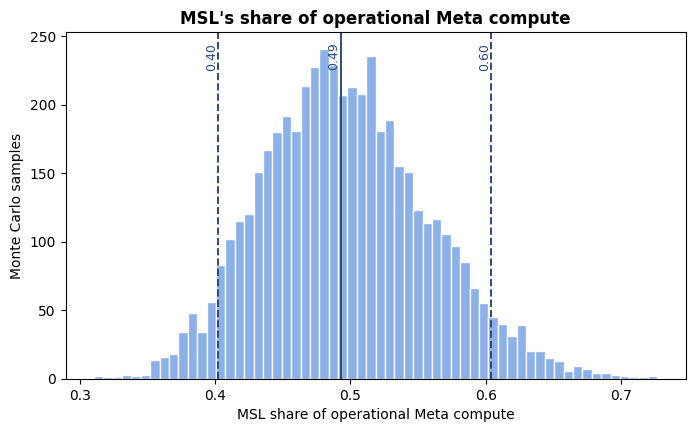

In [4]:
msl_share = sq.to(0.4, 0.6, lclip=0.1, rclip=0.9)
msl_share_samples = msl_share @ N_SAMPLES

p = summary("MSL share of operational compute", msl_share_samples)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(msl_share_samples, bins=60, color="#7FA9E6", alpha=0.9,
        edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(p[q], color="#2B4A7E", ls=style, lw=1.4)
    ax.text(p[q], ax.get_ylim()[1] * 0.97, f"{p[q]:.2f}", rotation=90,
            va="top", ha="right", fontsize=9, color="#2B4A7E")
ax.set_xlabel("MSL share of operational Meta compute")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("MSL's share of operational Meta compute", weight="bold")
plt.show()

In [5]:
msl_compute = operational * msl_share_samples

summary("MSL H100e", msl_compute);

MSL H100e
  90% CI : 610k – 1.21M
  median : 848k
  mean   : 869k


## Monte Carlo summary

The MSL total is exactly the product of three sampled parameters:

> `MSL H100e = total_owned × deployment_lag × MSL_share`

Unlike the DeepMind model there is no blended-fraction step — the share is
sampled directly. Each row below shows one input parameter: the error bar
spans the 90% credible interval, with a dot at the median. The left column
reads out the multiplication chain at medians.

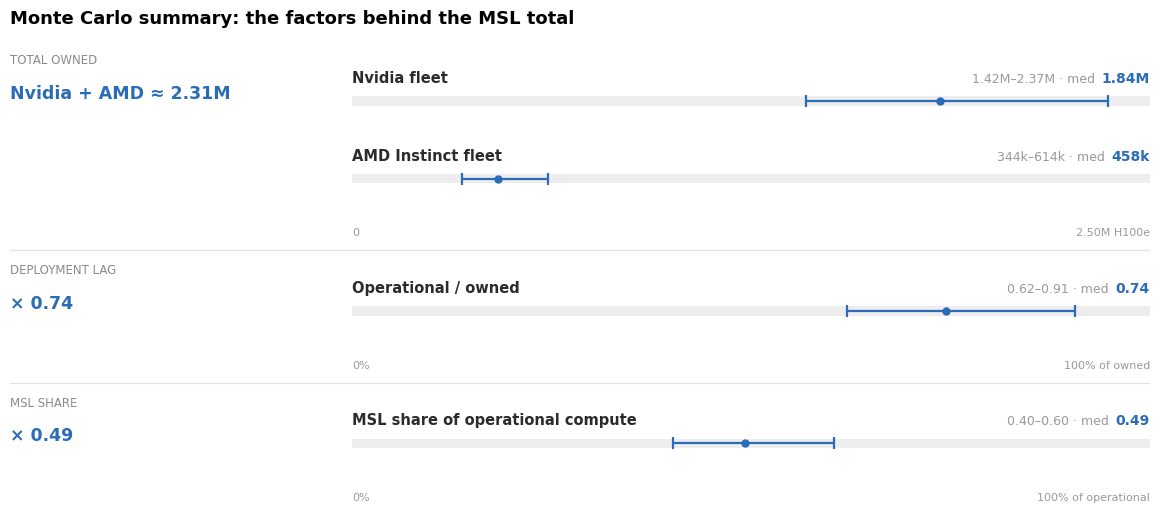

In [6]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]


def label_spans_right(ax, x, y, spans, pad_px=7):
    """Draw text spans (given left-to-right) so they end right-aligned at data-x."""
    for txt, kw in reversed(spans):
        t = ax.text(x, y, txt, ha="right", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x0 - pad_px, 0))[0]


owned_scale = 2.5 * M  # a bit above the Nvidia fleet's 95th percentile

sections = [
    dict(kicker="TOTAL OWNED",
         headline=f"Nvidia + AMD ≈ {fmt(np.median(total_owned))}",
         rows=[("Nvidia fleet", nvidia_samples),
               ("AMD Instinct fleet", amd_samples)],
         scale=owned_scale,
         axis_labels=("0", f"{fmt(owned_scale)} H100e")),
    dict(kicker="DEPLOYMENT LAG",
         headline=f"× {np.median(deployment_lag_samples):.2f}",
         rows=[("Operational / owned", deployment_lag_samples)],
         scale=1.0,
         axis_labels=("0%", "100% of owned")),
    dict(kicker="MSL SHARE",
         headline=f"× {np.median(msl_share_samples):.2f}",
         rows=[("MSL share of operational compute", msl_share_samples)],
         scale=1.0,
         axis_labels=("0%", "100% of operational")),
]

ROW_H, FOOTER_H = 1.0, 0.7
height_units = sum(len(s["rows"]) for s in sections) * ROW_H + FOOTER_H * len(sections)

fig, ax = plt.subplots(figsize=(12, 0.78 * height_units + 0.7))
fig.subplots_adjust(left=0.03, right=0.98, top=0.9, bottom=0.03)
ax.set_xlim(0, 1)
ax.set_ylim(0, height_units)
ax.axis("off")

BAR_X0, BAR_X1 = 0.30, 1.00
y = height_units
for i, sec in enumerate(sections):
    fr = fmt if sec["scale"] > 10 else (lambda v: f"{v:.2f}")
    # left column: section kicker plus the factor it contributes at medians
    ax.text(0, y - 0.34, sec["kicker"], fontsize=8.5, color="#8a8a8a",
            va="bottom")
    ax.text(0, y - 0.80, sec["headline"], fontsize=12.5, fontweight="bold",
            color="#2B6CB8", va="bottom")
    for name, samples in sec["rows"]:
        y -= ROW_H
        lo, med, hi = np.percentile(samples, [5, 50, 95])
        to_x = lambda v: BAR_X0 + (v / sec["scale"]) * (BAR_X1 - BAR_X0)
        ax.text(BAR_X0, y + 0.42, name, fontsize=10.5, fontweight=600,
                color="#2b2b2b", va="bottom")
        label_spans_right(ax, BAR_X1, y + 0.42, [
            (f"{fr(lo)}–{fr(hi)} · med", dict(fontsize=9, color="#999999")),
            (fr(med), dict(fontsize=10, fontweight="bold", color="#2B6CB8")),
        ])
        # full-axis track, then the 90% CI as an error bar with a median dot
        ax.barh(y + 0.22, BAR_X1 - BAR_X0, left=BAR_X0, height=0.12,
                color="#EDEDED", zorder=1)
        ax.errorbar(to_x(med), y + 0.22,
                    xerr=[[to_x(med) - to_x(lo)], [to_x(hi) - to_x(med)]],
                    fmt="o", ms=5, color="#2B6CB8", ecolor="#2B6CB8",
                    elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    # section footer (axis extent hints) and divider
    y -= FOOTER_H
    ax.text(BAR_X0, y + 0.16, sec["axis_labels"][0], fontsize=8,
            color="#9a9a9a", va="bottom")
    ax.text(BAR_X1, y + 0.16, sec["axis_labels"][1], fontsize=8,
            color="#9a9a9a", va="bottom", ha="right")
    if i < len(sections) - 1:
        ax.axhline(y, color="#e3e3e3", lw=0.8)

ax.set_title("Monte Carlo summary: the factors behind the MSL total",
             loc="left", fontsize=13, weight="bold", pad=12)
plt.show()

## Final visualization

Three magnitudes on one axis: owned and operational run to their medians
(CIs in the labels), while the MSL bar runs to its median with an error bar
spanning its 90% interval.

The median lands a bit under 1M H100e — consistent with the bottom line in
the modeling summary (MSL ≈ half of Meta's ~2.3M owned, less after
deployment lag). Even the 95th percentile sits below OpenAI's central ~1.7M
estimate, supporting the conclusion that MSL likely had less compute than
OpenAI at end-2025.

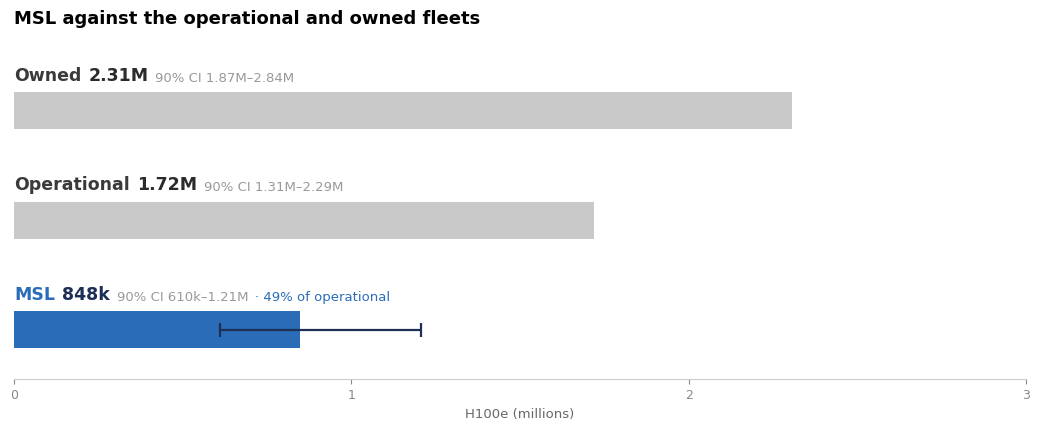

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 3)
ax.set_ylim(-0.45, 2.62)

bar_h = 0.34
share_of_op = np.median(msl_share_samples)

for name, samples, y in [("Owned", total_owned, 2),
                         ("Operational", operational, 1),
                         ("MSL", msl_compute, 0)]:
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    is_lab = name == "MSL"
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold",
                    color="#2B6CB8" if is_lab else "#3a3a3a")),
        (fmt(med), dict(fontsize=12.5, fontweight="bold",
                        color="#1d2f54" if is_lab else "#2b2b2b")),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if is_lab:
        # bar to the median, error bar spanning the 90% CI
        ax.barh(y, med / 1e6, height=bar_h, color="#2B6CB8")
        ax.errorbar(med / 1e6, y,
                    xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                    fmt="none", ecolor="#1d2f54", elinewidth=1.6,
                    capsize=5, capthick=1.6, zorder=3)
        spans.append((f"· {share_of_op:.0%} of operational",
                      dict(fontsize=9.5, color="#2B6CB8")))
    else:
        ax.barh(y, med / 1e6, height=bar_h, color="#C9C9C9")
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks(range(0, 4))
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("MSL against the operational and owned fleets",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity check: widening the MSL-share uncertainty

The base 0.4–0.6 CI takes the mid-2025 analyst split roughly at face value.
But the 50:50 center is a point estimate, and there are reasons to want a
wider CI: how far the late-2025 pivot had actually shifted allocation by
December, and what counts as MSL at all. Here we re-run the model under
progressively wider share CIs — all the way out to the 0.1–0.9 hard bounds —
reusing the same owned-fleet and deployment-lag draws so the only thing that
changes is the share spread:

- **0.40–0.60** — baseline.
- **0.33–0.73** — 2× the baseline log-width, geometric median (~0.49) held
  fixed.
- **0.27–0.90** — 3× the log-width; the top of the CI touches the 0.9 hard
  bound.
- **0.10–0.90, uniform** — the limit case: any split between the 10:90 and
  90:10 hard bounds is equally likely. (A lognormal this wide centered near
  0.5 isn't possible — its geometric median would slide down to 0.3 — so the
  limit case switches to a uniform.)

Each bar runs to the median of the resulting MSL distribution, with an
error bar spanning the 90% interval. Because the center is held at ~50:50,
the median barely moves — widening the share only stretches the tails.
Even the widest cases top out around 1.6M at the 95th percentile,
approaching but not reaching OpenAI's central ~1.7M.

                    share CI       5th    median      95th   90% CI width
        0.40–0.60 (baseline)      610k      848k     1.21M           595k
    0.33–0.73 (2× log-width)      533k      845k     1.38M           848k
    0.27–0.90 (3× log-width)      430k      848k     1.58M          1.15M
         0.10–0.90 (uniform)      240k      840k     1.60M          1.36M

Medians stay pinned near 848k throughout; the widest case grows the 90% CI width +128% and its 95th percentile reaches 1.60M.


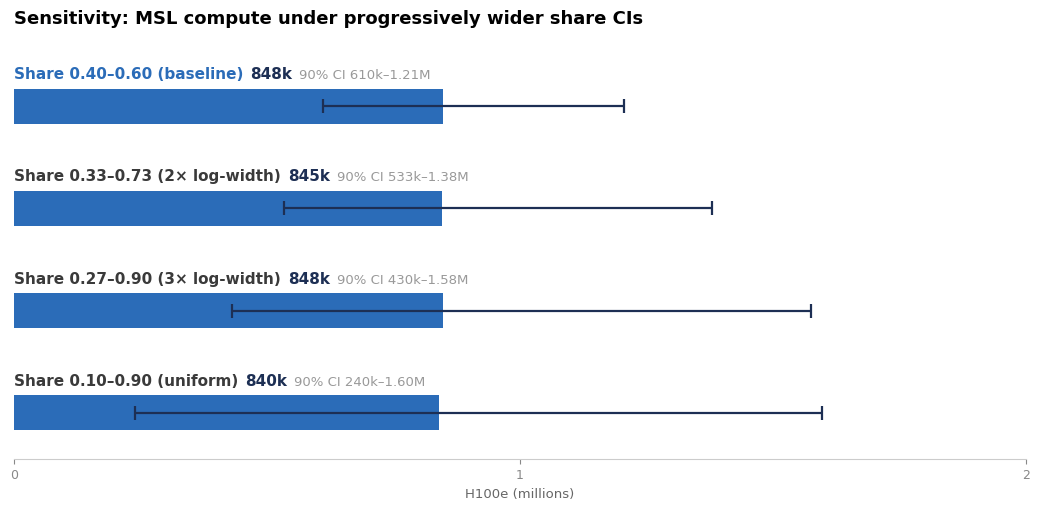

In [8]:
# Progressively wider share CIs. The lognormal rows hold the geometric median
# (~0.49) fixed; the uniform row is the maximal-uncertainty limit between the
# hard bounds. Owned and lag draws are reused so only the share spread changes.
share_scenarios = [
    ("0.40–0.60 (baseline)", msl_share_samples),
    ("0.33–0.73 (2× log-width)",
     sq.to(0.33, 0.73, lclip=0.1, rclip=0.9) @ N_SAMPLES),
    ("0.27–0.90 (3× log-width)",
     sq.to(0.27, 0.90, lclip=0.1, rclip=0.9) @ N_SAMPLES),
    ("0.10–0.90 (uniform)", sq.uniform(0.1, 0.9) @ N_SAMPLES),
]

rows = []
print(f"{'share CI':>28}  {'5th':>8}  {'median':>8}  {'95th':>8}  {'90% CI width':>13}")
for label, share_samples in share_scenarios:
    pc = sq.get_percentiles(operational * share_samples, percentiles=[5, 50, 95])
    rows.append((label, pc[5], pc[50], pc[95]))
    print(f"{label:>28}  {fmt(pc[5]):>8}  {fmt(pc[50]):>8}  {fmt(pc[95]):>8}  "
          f"{fmt(pc[95] - pc[5]):>13}")

base_width = rows[0][3] - rows[0][1]
widest = rows[-1]
print(f"\nMedians stay pinned near {fmt(rows[0][2])} throughout; the widest case "
      f"grows the 90% CI width {(widest[3] - widest[1]) / base_width - 1:+.0%} "
      f"and its 95th percentile reaches {fmt(widest[3])}.")

fig, ax = plt.subplots(figsize=(11, 5.4))
fig.subplots_adjust(left=0.05, right=0.97, top=0.88, bottom=0.11)
ax.set_xlim(0, 2)
ax.set_ylim(-0.45, len(rows) - 1 + 0.62)

bar_h = 0.34
for i, (label, lo, med, hi) in enumerate(rows):
    y = len(rows) - 1 - i
    # same encoding as the fleet chart: bar to the median, error bar across
    # the 90% interval
    ax.barh(y, med / 1e6, height=bar_h, color="#2B6CB8")
    ax.errorbar(med / 1e6, y, xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                fmt="none", ecolor="#1d2f54", elinewidth=1.6, capsize=5,
                capthick=1.6, zorder=3)
    label_spans(ax, 0, y + 0.24, [
        (f"Share {label}", dict(fontsize=11, fontweight="bold",
                                color="#2B6CB8" if i == 0 else "#3a3a3a")),
        (fmt(med), dict(fontsize=11, fontweight="bold", color="#1d2f54")),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ])

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks(range(0, 3))
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("Sensitivity: MSL compute under progressively wider share CIs",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity check: discrete deployment-lag scenarios

The base case folds deployment lag into one lognormal (0.5–2 quarters as the
90% CI). Reference points from CoreWeave suggest installs took ~3 months in
early 2025 and "within weeks" by late 2025, but Meta's own ramp could be
slower (power constraints, the Hyperion/Prometheus builds). Here we instead
**fix** the lag at discrete scenarios from 0 to 3 quarters — mapping each
lag to an operational/owned ratio via Meta's quarterly stock trajectory,
interpolating between quarter ends for the half-quarter steps — and reuse
the same owned-fleet and share draws so only the lag changes. The modeling
summary's default is a 1-quarter lag.

lag (q)  ratio       5th    median      95th
    0.0   1.00      852k     1.13M     1.53M
    0.5   0.90      766k     1.02M     1.37M
    1.0   0.79      673k      895k     1.21M
    1.5   0.70      596k      793k     1.07M
    2.0   0.62      528k      703k      947k
    3.0   0.48      409k      544k      733k

Default 1-quarter lag: median 895k, 90% CI 673k – 1.21M.
Across 0–3 quarters the median spans 544k – 1.13M.


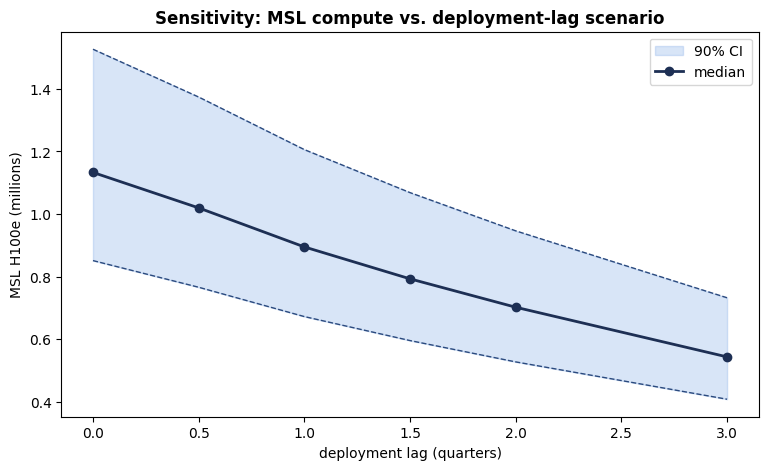

In [9]:
# Lag (quarters) -> operational/owned ratio, read off Meta's quarterly stocks
# (~2.30M end-Q4, ~1.83M end-Q3, ~1.42M end-Q2, ~1.10M end-Q1 2025).
lag_scenarios = [
    (0.0, 1.00),
    (0.5, 0.90),
    (1.0, 0.79),
    (1.5, 0.70),
    (2.0, 0.62),
    (3.0, 0.48),
]

rows = []
for lag_q, ratio in lag_scenarios:
    msl = total_owned * ratio * msl_share_samples
    pc = sq.get_percentiles(msl, percentiles=[5, 50, 95])
    rows.append((lag_q, ratio, pc[5], pc[50], pc[95]))

print(f"{'lag (q)':>7}  {'ratio':>5}  {'5th':>8}  {'median':>8}  {'95th':>8}")
for lag_q, ratio, lo, med, hi in rows:
    print(f"{lag_q:>7.1f}  {ratio:>5.2f}  {fmt(lo):>8}  {fmt(med):>8}  {fmt(hi):>8}")

one_q = next(r for r in rows if r[0] == 1.0)
print(f"\nDefault 1-quarter lag: median {fmt(one_q[3])}, "
      f"90% CI {fmt(one_q[2])} – {fmt(one_q[4])}.")
print(f"Across 0–3 quarters the median spans "
      f"{fmt(rows[-1][3])} – {fmt(rows[0][3])}.")

lags = [r[0] for r in rows]
los = np.array([r[2] for r in rows]) / 1e6
meds = np.array([r[3] for r in rows]) / 1e6
his = np.array([r[4] for r in rows]) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(lags, los, his, color="#7FA9E6", alpha=0.30, label="90% CI")
ax.plot(lags, his, "--", color="#2B4A7E", lw=1)
ax.plot(lags, los, "--", color="#2B4A7E", lw=1)
ax.plot(lags, meds, "o-", color="#1d2f54", lw=2, label="median")
ax.set_xlabel("deployment lag (quarters)")
ax.set_ylabel("MSL H100e (millions)")
ax.set_title("Sensitivity: MSL compute vs. deployment-lag scenario",
             weight="bold")
ax.legend()
plt.show()